PERSONALISATION

In [14]:
%cd /content
!rm -rf breath_aac
!git clone https://github.com/naflanawas/breath_aac.git
%cd breath_aac
!git checkout main_dev


/content
Cloning into 'breath_aac'...
remote: Enumerating objects: 157, done.
remote: Counting objects: 100% (157/157), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 157 (delta 64), reused 118 (delta 34), pack-reused 0 (from 0)
Receiving objects: 100% (157/157), 667.61 KiB | 24.73 MiB/s, done.
Resolving deltas: 100% (64/64), done.
/content/breath_aac
Branch 'main_dev' set up to track remote branch 'main_dev' from 'origin'.
Switched to a new branch 'main_dev'


In [21]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
#!unzip -q "/content/drive/MyDrive/FYP_2025/Implementation/models.zip" -d /content/breath_aac/
#!ls models | head

!unzip -q "/content/drive/MyDrive/fyp/models.zip" -d /content/breath_aac/
!unzip -q "/content/drive/MyDrive/fyp/features.zip" -d /content/breath_aac/
!ls models | head
!ls features | head


ms_tcn_colab_1024.pt
ms_tcn_local_256.pt
mel_dd_subjectwise


In [23]:
import pandas as pd

SPLIT_CSV = "manifests/split_2c_subjectwise.csv"
K = 5

df = pd.read_csv(SPLIT_CSV)
test_df = df[df["split"] == "test"].copy()

# count samples per (subject, label)
counts = test_df.groupby(["subject_id", "label"]).size().unstack(fill_value=0)

# subjects that don't have enough for BOTH classes
bad = counts[(counts.min(axis=1) < K)]

print("Total test subjects:", counts.shape[0])
print(f"Subjects with < {K} samples in at least one class:", bad.shape[0])

# show a few
display(bad.head(20))


Total test subjects: 382
Subjects with < 5 samples in at least one class: 382


label,long,short
subject_id,,
05bieNLXPuaIWEVaX81EkbbjVrh1,1,1
0Js6ZUZQ9NUnu568Fh7B6mZ1R8o1,1,1
0c00ybTdnIRUTXeg20bZjJOzhKv1,1,1
0drfnqVwccT6UmgVLQEuyVglDC23,1,1
0eQAE4NgLUWYqAaMuWoO4XgIgvF2,1,1
0mkAUAbpROMIFjKpdFxlUnYTV262,1,1
0sIeyohqXMOGTqPA7RiiuyJ3AOt2,1,1
0zUxdfS5aoS6SiEoF1x6JXOk25B3,1,1
1B70um5alIc8VeCeJmosZsSuPTm2,1,1


In [16]:
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

from src.train.train_ms_tcn_2c import MSTCN, pick_device
from src.features.protonet import compute_prototypes, prototypical_predict


In [17]:
SPLIT_CSV = "manifests/split_2c_subjectwise.csv"
CKPT = "models/ms_tcn_colab_1024.pt"

MAX_LEN = 1024
WINDOW_STRIDE = 512
K = 5
SEED = 7



In [18]:
df = pd.read_csv(SPLIT_CSV)

classes = sorted(df[df["split"] == "train"]["label"].unique())
c2i = {c:i for i,c in enumerate(classes)}
i2c = {i:c for c,i in c2i.items()}

print("Classes:", classes)


Classes: ['long', 'short']


In [24]:
device = pick_device()
print("Device:", device)

model = MSTCN(in_ch=3, n_classes=len(classes)).to(device)
model.load_state_dict(torch.load(CKPT, map_location=device), strict=False)
model.eval()

for p in model.parameters():
    p.requires_grad = False

print("Loaded checkpoint:", CKPT)


Device: cuda
Loaded checkpoint: models/ms_tcn_colab_1024.pt


In [25]:
def split_into_windows(x, win_len=1024, stride=512):
    """
    x: [3, 64, T]
    returns list of [3, 64, win_len]
    """
    _, _, T = x.shape
    windows = []

    if T < win_len:
        pad = np.zeros((3, 64, win_len - T), dtype=x.dtype)
        windows.append(np.concatenate([x, pad], axis=-1))
        return windows

    for start in range(0, T - win_len + 1, stride):
        windows.append(x[:, :, start:start + win_len])

    return windows


In [26]:
def load_npy_as_windows(path, win_len=1024, stride=512):
    x = np.load(path)  # [3,64,T]

    # CMVN (same as training)
    mean = x.mean(axis=(1,2), keepdims=True)
    std  = x.std(axis=(1,2), keepdims=True) + 1e-8
    x = (x - mean) / std

    windows = split_into_windows(x, win_len, stride)
    return [torch.from_numpy(w).float() for w in windows]


In [35]:
def embed_windows(windows_list):
    if len(windows_list) == 0:
        return None
    X = torch.stack(windows_list).to(device)
    with torch.no_grad():
        emb = model(X, return_embedding=True)
    return emb.cpu()


In [28]:
test_df = df[df["split"] == "test"].copy()
subjects = sorted(test_df["subject_id"].unique())

print("Number of test subjects:", len(subjects))


Number of test subjects: 382


PROTONET IMPL


In [36]:
WINDOW_LEN = 1024
WINDOW_STRIDE = 512

rng = np.random.default_rng(SEED)

all_true_global, all_pred_global = [], []
all_true_proto,  all_pred_proto  = [], []
per_subject_rows = []

for sid in subjects:
    sdf = test_df[test_df["subject_id"] == sid]

    # collect windows per class
    windows_long, windows_short = [], []

    for _, row in sdf.iterrows():
        windows = load_npy_as_windows(
            row["filepath"],
            win_len=WINDOW_LEN,
            stride=WINDOW_STRIDE
        )
        if row["label"] == "long":
            windows_long.extend(windows)
        else:
            windows_short.extend(windows)

    # dynamic K (WINDOW level)
    k_subj = min(K, len(windows_long), len(windows_short))
    if k_subj < 1:
        continue

    # sample SUPPORT windows
    sup_long  = rng.choice(len(windows_long),  k_subj, replace=False)
    sup_short = rng.choice(len(windows_short), k_subj, replace=False)

    support_windows = (
        [windows_long[i] for i in sup_long] +
        [windows_short[i] for i in sup_short]
    )
    support_labels = torch.tensor(
        [c2i["long"]]*k_subj + [c2i["short"]]*k_subj
    )

    # QUERY windows = rest
    qry_long  = [w for i,w in enumerate(windows_long)  if i not in sup_long]
    qry_short = [w for i,w in enumerate(windows_short) if i not in sup_short]

    if len(qry_long) + len(qry_short) == 0:
        continue

    query_windows = qry_long + qry_short
    query_labels = torch.tensor(
        [c2i["long"]]*len(qry_long) + [c2i["short"]]*len(qry_short)
    )

    # ---- embeddings ----
    sup_emb = embed_windows(support_windows)
    qry_emb = embed_windows(query_windows)

    # ---- ProtoNet ----
    prototypes = compute_prototypes(sup_emb, support_labels, n_classes=2)
    proto_preds = prototypical_predict(qry_emb, prototypes)

    # ---- Global ----
    Xq = torch.stack(query_windows).to(device)
    with torch.no_grad():
        global_preds = model(Xq).argmax(dim=1).cpu()

    # collect
    all_true_proto.extend(query_labels.numpy())
    all_pred_proto.extend(proto_preds.numpy())
    all_true_global.extend(query_labels.numpy())
    all_pred_global.extend(global_preds.numpy())

    per_subject_rows.append([
        sid,
        k_subj,
        len(query_labels),
        accuracy_score(query_labels, global_preds),
        f1_score(query_labels, global_preds, average="macro"),
        accuracy_score(query_labels, proto_preds),
        f1_score(query_labels, proto_preds, average="macro"),
    ])

print("Done subjects:", len(per_subject_rows))


Done subjects: 51


In [37]:
res = pd.DataFrame(
    per_subject_rows,
    columns=["subject_id", "k_used", "n_query", "global_acc", "global_f1", "proto_acc", "proto_f1"]
)

display(res.head())

print("\n=== GLOBAL MODEL ===")
print("Acc:", accuracy_score(all_true_global, all_pred_global))
print("F1 :", f1_score(all_true_global, all_pred_global, average="macro"))

print("\n=== PROTONET (PERSONALISED) ===")
print("Acc:", accuracy_score(all_true_proto, all_pred_proto))
print("F1 :", f1_score(all_true_proto, all_pred_proto, average="macro"))


,subject_id,k_used,n_query,global_acc,global_f1,proto_acc,proto_f1
0,0zUxdfS5aoS6SiEoF1x6JXOk25B3,1,1,1.0,1.0,1.0,1.0
1,1BVg9qHEPjhmnnl7CHMSkZRCHiR2,1,1,1.0,1.0,1.0,1.0
2,1C6BCvPkrjT62P0843qRIsRPClF2,1,1,1.0,1.0,1.0,1.0
3,269e2kDksfRXKVHNXf4ACl9JUVm1,1,1,1.0,1.0,1.0,1.0
4,2JEOCn5AtuQh5Skzhzf5ASuIC9z1,1,1,0.0,0.0,0.0,0.0



=== GLOBAL MODEL ===
Acc: 0.8627450980392157
F1 : 0.4631578947368421

=== PROTONET (PERSONALISED) ===
Acc: 0.8627450980392157
F1 : 0.7736207989854154


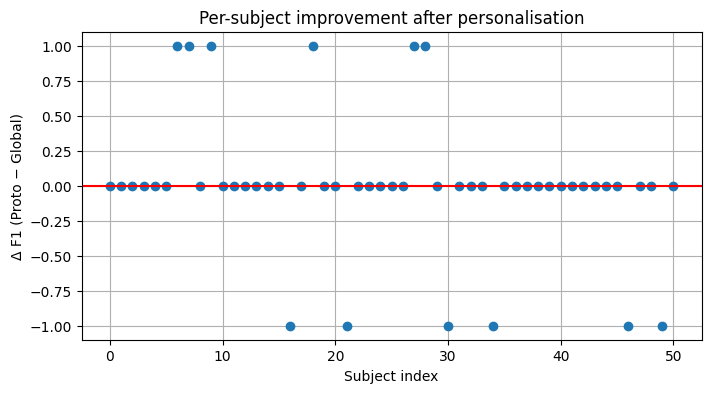

In [38]:
plt.figure(figsize=(8,4))
plt.plot(res["proto_f1"] - res["global_f1"], marker="o", linestyle="none")
plt.axhline(0, color="red")
plt.xlabel("Subject index")
plt.ylabel("Δ F1 (Proto − Global)")
plt.title("Per-subject improvement after personalisation")
plt.grid(True)
plt.show()
